In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
log_path = Path("/home/woody/iwi5/iwi5362h/logs/albef_A0_3587030.out")

In [11]:
pattern = re.compile(
    r"Averaged stats:\s*"
    r"lr:\s*([0-9.eE+-]+)\s+"
    r"loss_mlm:\s*([0-9.eE+-]+)\s+"
    r"loss_ita:\s*([0-9.eE+-]+)\s+"
    r"loss_itm:\s*([0-9.eE+-]+)\s+"
    r"loss_support:\s*([0-9.eE+-]+)\s+"
    r"attn_inside:\s*([0-9.eE+-]+)\s+"
    r"attn_outside:\s*([0-9.eE+-]+)\s+"
    r"support_active:\s*([0-9.eE+-]+)"
)

rows = []

with open(log_path, "r") as f:
    epoch_idx = 0

    for line in f:
        match = pattern.search(line)

        if match:
            rows.append({
                "epoch": epoch_idx,
                "lr": float(match.group(1)),
                "loss_mlm": float(match.group(2)),
                "loss_ita": float(match.group(3)),
                "loss_itm": float(match.group(4)),
                "loss_support": float(match.group(5)),
                "attn_inside": float(match.group(6)),
                "attn_outside": float(match.group(7)),
                "support_active": float(match.group(8)),
            })

            epoch_idx += 1

df = pd.DataFrame(rows)

print(df)
print("epochs found:", len(df))

    epoch      lr  loss_mlm  loss_ita  loss_itm  loss_support  attn_inside  \
0       0  0.0001    0.4962    6.9960    0.6370           0.0          0.0   
1       1  0.0001    0.0945    7.6179    0.6337           0.0          0.0   
2       2  0.0001    0.0908    7.5096    0.6322           0.0          0.0   
3       3  0.0001    0.1337    7.5589    0.6317           0.0          0.0   
4       4  0.0001    0.0787    7.5411    0.6299           0.0          0.0   
5       5  0.0001    0.0745    7.4885    0.6281           0.0          0.0   
6       6  0.0001    0.1080    7.5107    0.6258           0.0          0.0   
7       7  0.0001    0.0800    7.5483    0.6257           0.0          0.0   
8       8  0.0001    0.1141    7.5311    0.6233           0.0          0.0   
9       9  0.0001    0.0982    7.5447    0.6254           0.0          0.0   
10     10  0.0001    0.0902    7.5172    0.6231           0.0          0.0   
11     11  0.0001    0.0811    7.4944    0.6238           0.0   

In [12]:
df["loss_total"] = (
    df["loss_mlm"]
    + df["loss_ita"]
    + df["loss_itm"]
    + df["loss_support"]
)

df

,epoch,lr,loss_mlm,loss_ita,loss_itm,loss_support,attn_inside,attn_outside,support_active,loss_total
0,0,0.0001,0.4962,6.9960,0.6370,0.0,0.0,0.0,0.0,8.1292
1,1,0.0001,0.0945,7.6179,0.6337,0.0,0.0,0.0,0.0,8.3461
2,2,0.0001,0.0908,7.5096,0.6322,0.0,0.0,0.0,0.0,8.2326
3,3,0.0001,0.1337,7.5589,0.6317,0.0,0.0,0.0,0.0,8.3243
4,4,0.0001,0.0787,7.5411,0.6299,0.0,0.0,0.0,0.0,8.2497
5,5,0.0001,0.0745,7.4885,0.6281,0.0,0.0,0.0,0.0,8.1911
6,6,0.0001,0.1080,7.5107,0.6258,0.0,0.0,0.0,0.0,8.2445
7,7,0.0001,0.0800,7.5483,0.6257,0.0,0.0,0.0,0.0,8.2540
8,8,0.0001,0.1141,7.5311,0.6233,0.0,0.0,0.0,0.0,8.2685
9,9,0.0001,0.0982,7.5447,0.6254,0.0,0.0,0.0,0.0,8.2683


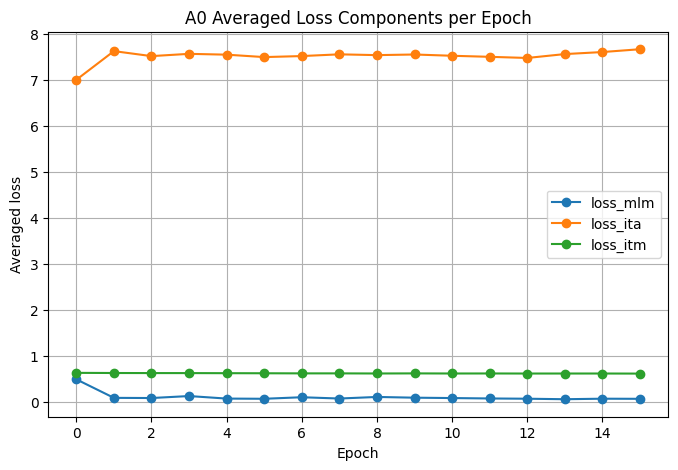

In [13]:
# Plot ALBEF loss components across epochs

plt.figure(figsize=(8, 5))

plt.plot(df["epoch"], df["loss_mlm"], marker="o", label="loss_mlm")
plt.plot(df["epoch"], df["loss_ita"], marker="o", label="loss_ita")
plt.plot(df["epoch"], df["loss_itm"], marker="o", label="loss_itm")

plt.xlabel("Epoch")
plt.ylabel("Averaged loss")
plt.title("A0 Averaged Loss Components per Epoch")
plt.legend()
plt.grid(True)
plt.show()